In [1]:
# 3. Import the required packages with their customary aliases as follows:

In [ ]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gdp_df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\gdp_per_capita.csv')
gdp_df
# there are 8465 rows and 4 columns
# data types include country, year, gdp (number), and a footnote

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [4]:
# 5. How many rows and columns are in `gdp_df`? 
# What are the data types of each column?

gdp_df.shape

# there are 8465 rows and 3 columns

(8465, 4)

In [5]:
#  6. Drop the `Value Footnotes` column and rename the remaining three to 
# 'Country', 'Year', and 'GDP_Per_Capita'.

gdp_df = gdp_df.drop(columns=['Value Footnotes']).rename(columns={'Country or Area': 'Country', 'Value': 'GDP_Per_Capita'})
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [6]:
# # 7. How many countries have data for all years?

count_years =  gdp_df['Year'].nunique()
count_years 

35

In [8]:
countries_year_counts = gdp_df.groupby('Country')['Year'].count()
countries_all_years = countries_year_counts[countries_year_counts == count_years]
countries_all_years

# There were 226 countries/regions that had gdp data for all years

Country
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
Andorra                        35
                               ..
Vanuatu                        35
Viet Nam                       35
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 226, dtype: int64

In [9]:
# Which countries are missing many years of data? 

countries_year_counts = gdp_df.groupby('Country')['Year'].count()
countries_some_years = countries_year_counts[countries_year_counts < count_years]
countries_some_years

# there were 21 countries or regions missing data for at least one year

Country
Afghanistan                  24
Bhutan                       34
Cayman Islands               18
CuraÃ§ao                     25
Djibouti                     12
Faroe Islands                17
Greenland                    34
Kosovo                       17
Lebanon                      34
Montenegro                   28
Palau                        34
San Marino                   27
Serbia                       30
Sint Maarten (Dutch part)    16
Somalia, Fed. Rep.           34
Syrian Arab Republic         33
Tonga                        34
Turks and Caicos Islands     18
Tuvalu                       34
Virgin Islands (US)          21
West Bank and Gaza           31
Name: Year, dtype: int64

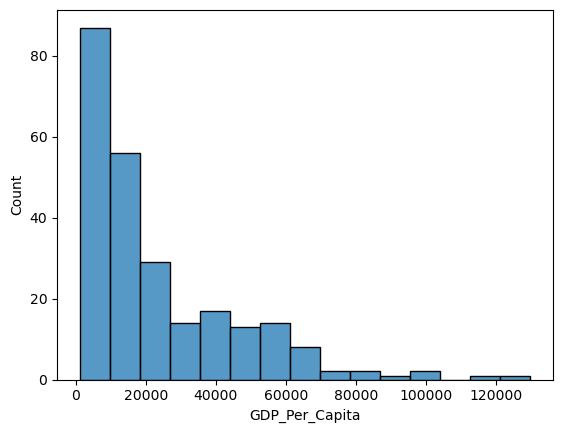

In [14]:
# In this question, 
# you're going to create some plots to show 
# the distribution of GDP per capita for the year 2020. 
# Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) 
# and look at the different types of plots under the Distribution section. 
# Create a histogram, a density plot, a boxplot, and a violin plot.
# What do you notice when you look at these plots?
# How do the plots compare and 
# what information can you get out of one type
# that you can't necessarily get out of the others?

# Create a histogram, a density plot, a boxplot, and a violin plot. 
gdp_2020 = gdp_df[gdp_df["Year"] == 2020]
gdp_2020

sns.histplot(data=gdp_2020, x="GDP_Per_Capita")
plt.show()

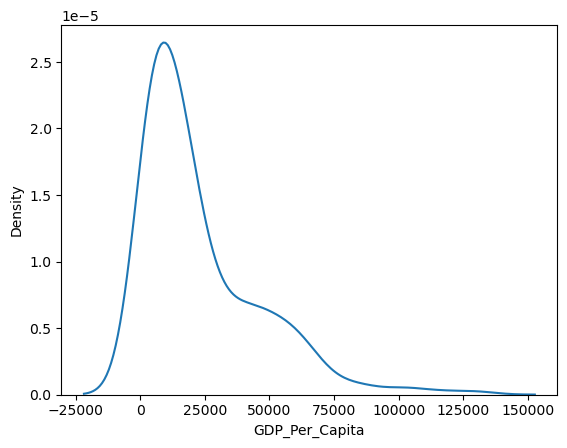

In [15]:
 # a density plot 
sns.kdeplot(data=gdp_2020, x="GDP_Per_Capita")
plt.show()

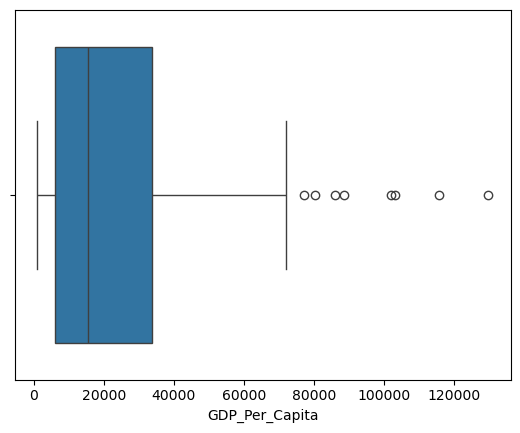

In [16]:
sns.boxplot(data=gdp_2020, x="GDP_Per_Capita")
plt.show()

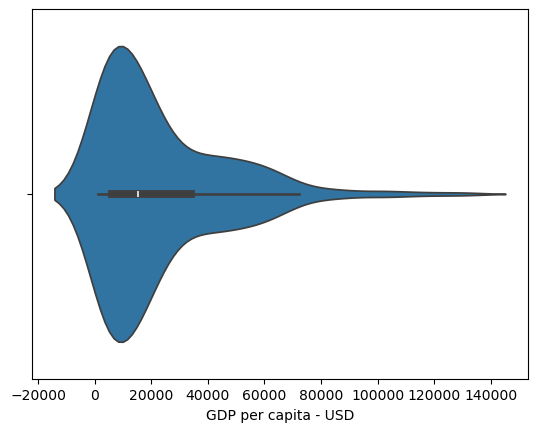

In [17]:
sns.violinplot(data=gdp_2020, x="GDP_Per_Capita")
plt.xlabel("GDP per capita - USD")
plt.show()

In [18]:
# 9. What was the median GDP per capita value in 2020?

median_2020 = gdp_2020["GDP_Per_Capita"].median()
median_2020


15399.308958012449

In [19]:
gdp_2020.describe()

,Year,GDP_Per_Capita
count,247.0,247.000000
mean,2020.0,23118.025650
std,0.0,22915.365686
min,2020.0,1030.770264
25%,2020.0,6046.008968
50%,2020.0,15399.308958
75%,2020.0,33899.203031
max,2020.0,129865.629988


In [20]:
# Start by subsetting your data to just these 4 years 
# into a new DataFrame named gdp_decades.

gdp_decades = gdp_df[gdp_df["Year"].isin([1990, 2000, 2010, 2020])].reset_index()
gdp_decades

,index,Country,Year,GDP_Per_Capita
0,3,Afghanistan,2020,2769.685745
1,13,Afghanistan,2010,2848.586061
2,23,Afghanistan,2000,1617.826475
3,28,Africa Eastern and Southern,2020,3978.931395
4,38,Africa Eastern and Southern,2010,3976.010989
...,...,...,...,...
961,8429,Zambia,1990,2425.111287
962,8434,Zimbabwe,2020,4527.719881
963,8444,Zimbabwe,2010,3885.393785
964,8454,Zimbabwe,2000,6170.333908


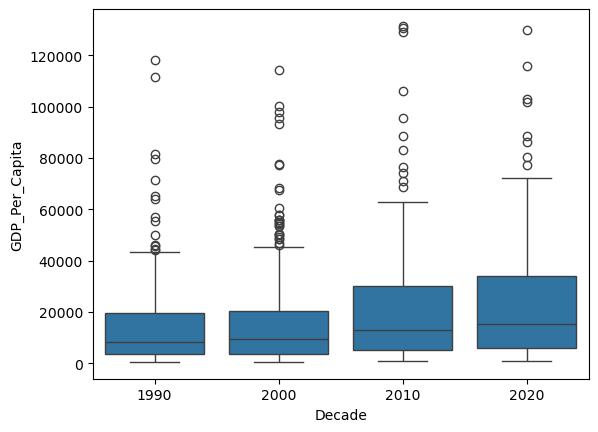

In [21]:
# 10. boxplot  

sns.boxplot(data=gdp_decades, x='Year', y='GDP_Per_Capita')
plt.xlabel("Decade")
plt.show()

# interesting to show how wealth inequality has stretched out, but not raised is floor

<BarContainer object of 966 artists>

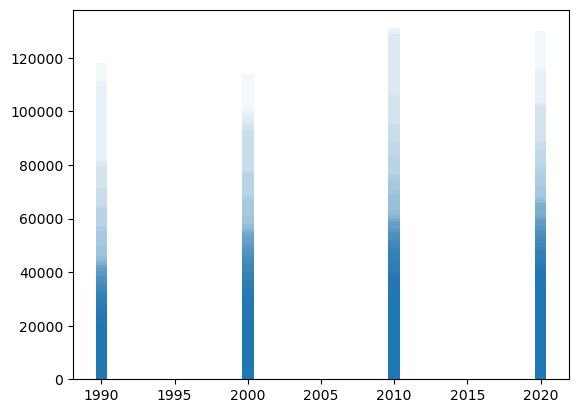

In [22]:
# 10. barplot 
plt.bar(x='Year',height='GDP_Per_Capita',data=gdp_decades, alpha=.05)
# good to show that low gdp is the global norm 

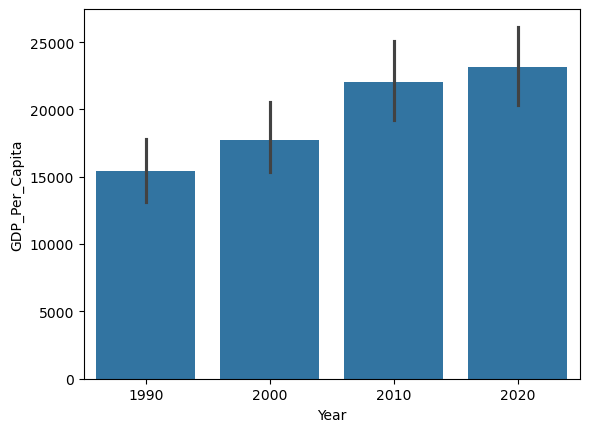

In [23]:
sns.barplot(data=gdp_decades, x='Year', y='GDP_Per_Capita')
plt.xlabel("Year")
plt.show()
# good to show the true mean of the data

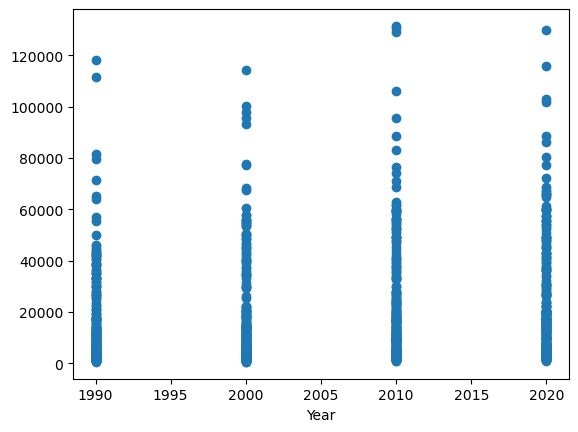

In [25]:
# 10. scatterplot

plt.scatter(data=gdp_decades,x='Year', y='GDP_Per_Capita')
plt.xlabel("Year")
plt.show()

# good to show the range of the data, and also how high gdp countries are outliers

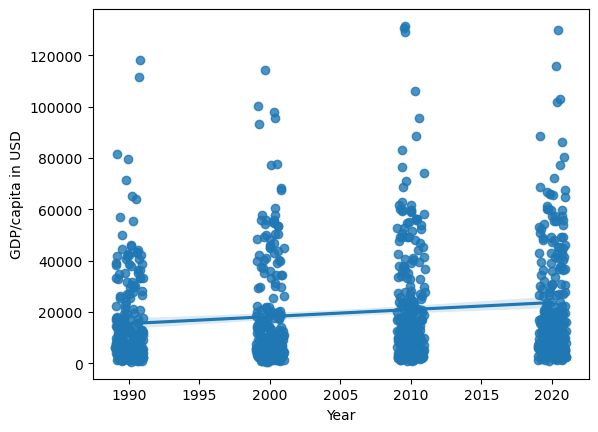

In [27]:
sns.regplot(data=gdp_decades,x='Year', y='GDP_Per_Capita', x_jitter = True)
plt.xlabel("Year")
plt.ylabel("GDP/capita in USD")
plt.show()
# decent to show the overall trend of increased gdp/capita but raises questions about inflation.

In [29]:
# 11. Which country was the first to have a GDP per capita greater than $100,000?

gdp_decades[gdp_decades["GDP_Per_Capita"]>100000][["Country", "Year", "GDP_Per_Capita"]].reset_index()
# Brunei and UAE in 1990

,index,Country,Year,GDP_Per_Capita
0,92,Bermuda,2010,105968.875104
1,117,Brunei Darussalam,2000,100323.439919
2,118,Brunei Darussalam,1990,118163.683370
3,419,Ireland,2020,101968.554362
4,529,Luxembourg,2020,129865.629988
5,530,Luxembourg,2010,131432.059616
6,531,Luxembourg,2000,114141.585296
7,534,"Macao SAR, China",2010,130758.280698
8,728,Qatar,2020,103061.899445
9,729,Qatar,2010,129044.708989


In [ ]:
# 12. Which country had the highest GDP per capita in 2020? 
# Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

gdp_2020.sort_values(by='GDP_Per_Capita',ascending=False)
# Luxembourg had the highest GDP per capita in 2020. (129865 USD)

In [30]:
lux_df = gdp_df[gdp_df["Country"]=="Luxembourg"][["Country", "Year", "GDP_Per_Capita"]]
lux_df

,Country,Year,GDP_Per_Capita
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


<Axes: xlabel='Year'>

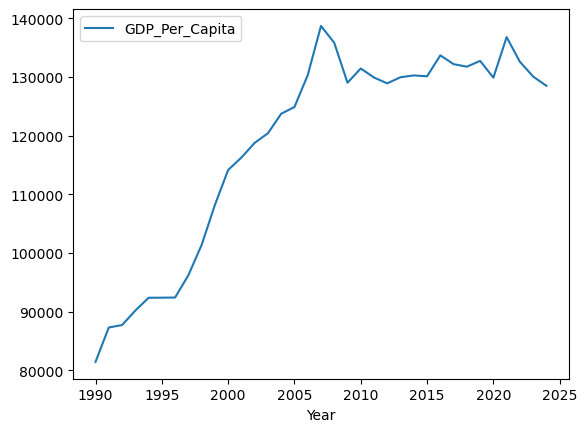

In [32]:
# Create a plot showing how Luxembourg's GDP per capita has changed over the timespan of the dataset.

# pd.plot(data=lux_df, x="Year", y="Value")
# plt.xlabel("GDP per capita - USD")
# plt.show()

lux_df.plot(x="Year", y="GDP_Per_Capita")

In [33]:
lux_df

,Country,Year,GDP_Per_Capita
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


In [35]:
# Which country had the lowest GDP per capita in 2020? 
# Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

gdp_2020.sort_values(by='GDP_Per_Capita')
# Burundi had the lowest GDP 

burundi_df = gdp_df[gdp_df["Country"] == "Burundi"]
burundi_df

,Country,Year,GDP_Per_Capita
1108,Burundi,2024,1051.259313
1109,Burundi,2023,1036.167122
1110,Burundi,2022,1031.254122
1111,Burundi,2021,1035.538574
1112,Burundi,2020,1030.770264
1113,Burundi,2019,1057.950060
1114,Burundi,2018,1046.595112
1115,Burundi,2017,1023.970406
1116,Burundi,2016,1009.635968
1117,Burundi,2015,995.319068


<Axes: xlabel='Year'>

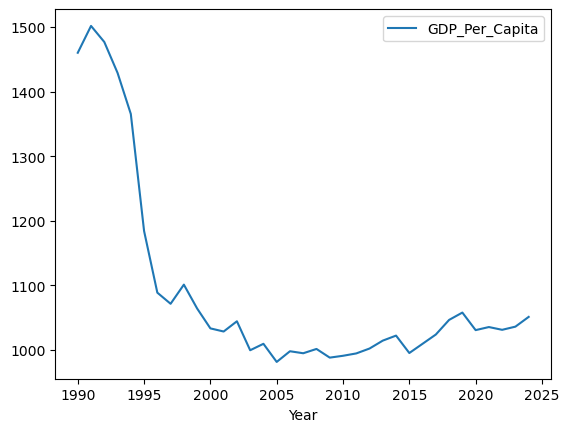

In [36]:
burundi_df.plot(x="Year", y="GDP_Per_Capita")

In [ ]:
# BONUS: Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? 
# Which countries had lower GDP per capita in 2020 than in 1990?

In [39]:
internet_df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\internet_use_per_capita.csv',
                         on_bad_lines='skip',
                         skipfooter=297,
                         engine='python'
)
internet_df.head()


,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.60,1
1,Afghanistan,2018,16.80,2
2,Afghanistan,2017,13.50,3
3,Afghanistan,2016,11.00,4
4,Afghanistan,2015,8.26,4


In [40]:
internet_df = internet_df.drop(columns=['Value Footnotes'])

In [41]:
internet_df = internet_df.rename(columns={"Country or Area": "Country", "Value":"Internet_Users_Pct"})
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [42]:
above_zero_pct = internet_df[internet_df['Internet_Users_Pct'] > 0]
sort_above_zero_pct = above_zero_pct.sort_values(by='Year')
sort_above_zero_pct
# above_zero_pct.sort_values(by='Year', ascending=False)

# 1990 is the first year to have non-zero internet users

,Country,Year,Internet_Users_Pct
1570,Denmark,1990,0.097277
2892,Japan,1990,0.020294
306,Australia,1990,0.585095
2034,France,1990,0.052778
339,Austria,1990,0.130369
...,...,...,...
427,Bangladesh,2023,44.502700
677,Bosnia and Herzegovina,2023,83.377200
1656,Ecuador,2023,72.694300
1537,Denmark,2023,98.775600


In [43]:
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


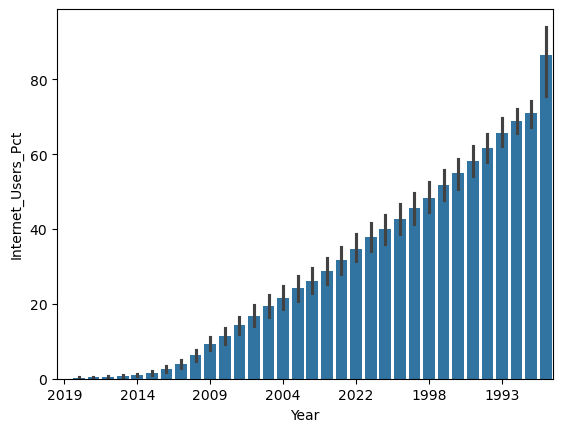

In [44]:
# 18. How does the distribution of internet users percent differ for 2000 and 2014?

internet_df_5 = sns.barplot(data=internet_df, x='Year', y='Internet_Users_Pct')
years = internet_df['Year'].unique()
internet_df_5.set_xticks(range(0, len(years), 5))
internet_df_5.set_xticklabels(years[::5])
plt.show()

In [45]:
internet_df_00_14 = internet_df[(internet_df['Year'] == 2014) | (internet_df['Year'] == 2000)]
internet_df_00_14

,Country,Year,Internet_Users_Pct
5,Afghanistan,2014,7.000000
28,Albania,2014,54.300000
42,Albania,2000,0.114097
57,Algeria,2014,29.500000
71,Algeria,2000,0.491706
...,...,...,...
6017,Yemen,2000,0.082500
6031,Zambia,2014,6.500000
6045,Zambia,2000,0.191072
6061,Zimbabwe,2014,16.364700


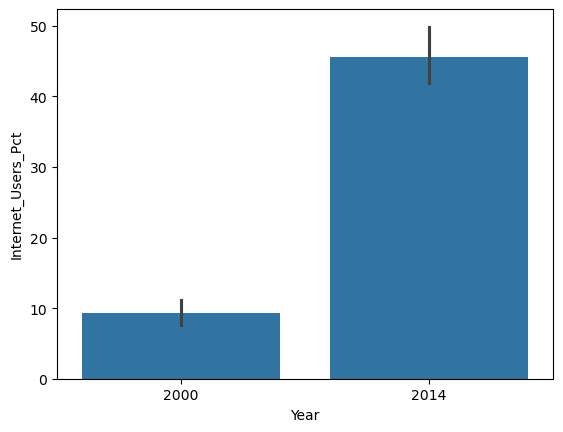

In [46]:
sns.barplot(data=internet_df_00_14,x='Year', y='Internet_Users_Pct')
plt.show()

In [47]:
# 19. For how many countries was the percentage of internet users below 5% in 2014?

internet_df_2014 = internet_df[(internet_df['Year'] == 2014) & (internet_df['Internet_Users_Pct'] < 5)]
internet_df_2014

,Country,Year,Internet_Users_Pct
873,Burundi,2014,1.04239
1033,Central African Republic,2014,2.70000
1061,Chad,2014,2.90000
1517,Democratic Republic of the Congo,2014,3.00000
1782,Eritrea,2014,0.99000
2451,Guinea-Bissau,2014,3.32000
3364,Madagascar,2014,3.70000
4073,Niger,2014,1.24868
5055,Somalia,2014,1.63000
5116,South Sudan,2014,2.60000


In [ ]:
# 20. Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. 
# Call the new DataFrame `gdp_and_internet_use`. 
#     Look at the first and last few rows to confirm that it merged correctly.



In [48]:
gdp_and_internet_use = gdp_df.merge(internet_df, how='outer', 
                left_on=['Year','Country'], 
                right_on=['Year','Country'],)

                                     


In [50]:
gdp_and_internet_use

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,1990,NaN,0.0
1,Africa Eastern and Southern,1990,3519.317545,NaN
2,Africa Western and Central,1990,4159.732102,NaN
3,Albania,1990,5291.156834,0.0
4,Algeria,1990,11728.545729,0.0
...,...,...,...,...
9775,Viet Nam,2024,14415.215953,NaN
9776,West Bank and Gaza,2024,3845.502974,NaN
9777,World,2024,21395.530889,NaN
9778,Zambia,2024,3708.069043,NaN


In [52]:
# gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014].sort_values(by='Internet_Users_Pct', 
#                                                                        ascending=False).head(3)
# Iceland, Falkland (Malvinas) Islands, Bermuda
top_3 = gdp_and_internet_use[(gdp_and_internet_use['Country'] == 'Iceland') | (gdp_and_internet_use['Country'] == 'Falkland (Malvinas) Islands') | (gdp_and_internet_use['Country'] == 'Bermuda') ]
top_3



,Country,Year,GDP_Per_Capita,Internet_Users_Pct
27,Bermuda,1990,79747.482503,0.000000
90,Falkland (Malvinas) Islands,1990,NaN,0.000000
126,Iceland,1990,42336.427188,0.000000
320,Bermuda,1991,76365.043054,NaN
396,Iceland,1991,41754.975891,0.505129
...,...,...,...,...
9133,Iceland,2022,65380.317305,99.856500
9321,Bermuda,2023,103052.348368,NaN
9400,Iceland,2023,68118.396031,NaN
9566,Bermuda,2024,109311.936941,NaN


In [ ]:
g = sns.FacetGrid(top_3, col="Country or Area")
g.map(sns.scatterplot, "Year", "Value")

In [ ]:
# 22. Subset `gdp_and_internet_use` to just the year 2014. 
#     Save this as a new dataframe named `gdp_and_internet_use_2014`.

gdp_and_internet_use_2014 = gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]
gdp_and_internet_use_2014

In [ ]:
g = sns.FacetGrid(gdp_and_internet_use_2014, col="Internet_Users_Pct")
g.map(sns.scatterplot, "Value", "Internet_Users_Pct")